# MNIST CNN Classifier


In [1]:
from pathlib import Path
import gzip
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.17.1


## Data

The repository includes the classic MNIST dataset as a compressed pickle, so the notebook does not depend on a network download. Images are 28×28 grayscale digits and labels range from 0 to 9.

In [2]:
def find_data_path():
    candidates = [Path("data/mnist.pkl.gz"), Path("../data/mnist.pkl.gz")]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Expected data/mnist.pkl.gz relative to the repository root")


data_path = find_data_path()
with gzip.open(data_path, "rb") as file:
    (x_train_full, y_train_full), (x_test, y_test) = pickle.load(file, encoding="bytes")

print("Training:", x_train_full.shape, y_train_full.shape)
print("Test:", x_test.shape, y_test.shape)

Training: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


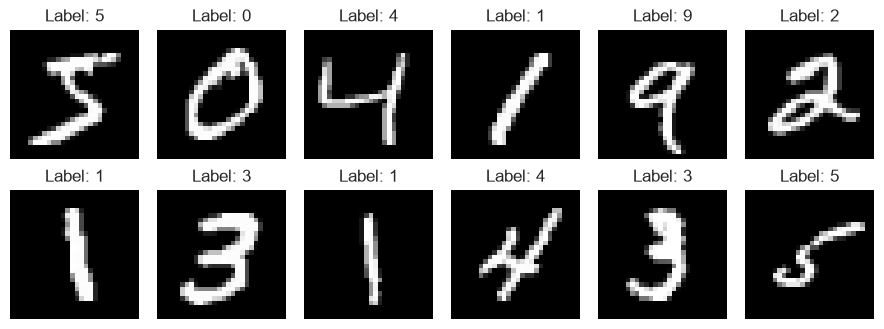

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3.5))
for image, label, ax in zip(x_train_full[:12], y_train_full[:12], axes.flat):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()

## Preprocessing

Pixel values are scaled to `[0, 1]` and a channel dimension is added for the CNN. A validation set is taken only from the training data, leaving the test set untouched until final evaluation. A 20,000-image training subset keeps this learning project quick to reproduce on CPU.

In [4]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train_full = x_train_full[..., np.newaxis]
x_test = x_test[..., np.newaxis]

rng = np.random.default_rng(SEED)
indices = rng.permutation(len(x_train_full))
train_idx = indices[:20_000]
val_idx = indices[20_000:25_000]

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (20000, 28, 28, 1)
Validation: (5000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## Model

Two convolution blocks learn local patterns such as edges and curves. Pooling reduces spatial size, while a small dense head maps the learned features to ten digit probabilities. Sparse categorical cross-entropy lets us keep integer labels instead of creating one-hot arrays.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [6]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=6,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/6


157/157 - 4s - 24ms/step - accuracy: 0.7905 - loss: 0.6952 - val_accuracy: 0.9390 - val_loss: 0.2031


Epoch 2/6


157/157 - 2s - 14ms/step - accuracy: 0.9391 - loss: 0.2019 - val_accuracy: 0.9636 - val_loss: 0.1158


Epoch 3/6


...

157/157 - 2s - 12ms/step - accuracy: 0.9669 - loss: 0.1065 - val_accuracy: 0.9748 - val_loss: 0.0794


Epoch 5/6


157/157 - 2s - 12ms/step - accuracy: 0.9736 - loss: 0.0860 - val_accuracy: 0.9754 - val_loss: 0.0748


Epoch 6/6


157/157 - 2s - 13ms/step - accuracy: 0.9770 - loss: 0.0742 - val_accuracy: 0.9792 - val_loss: 0.0662


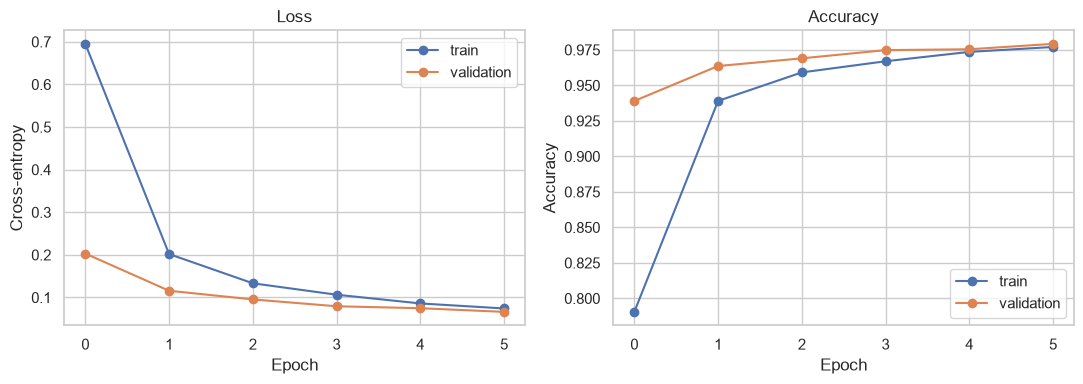

In [7]:
history_values = history.history
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_values["loss"], marker="o", label="train")
axes[0].plot(history_values["val_loss"], marker="o", label="validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()

axes[1].plot(history_values["accuracy"], marker="o", label="train")
axes[1].plot(history_values["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend()
plt.tight_layout()

## Evaluation

Accuracy gives the headline result. The class report and confusion matrix show which digits the model finds difficult, which is more informative than accuracy alone.

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
probabilities = model.predict(x_test, batch_size=256, verbose=0)
predictions = probabilities.argmax(axis=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, predictions, digits=4))

Test loss: 0.0578
Test accuracy: 0.9809
              precision    recall  f1-score   support

           0     0.9789    0.9939    0.9863       980
           1     0.9886    0.9921    0.9903      1135
           2     0.9730    0.9777    0.9754      1032
           3     0.9671    0.9891    0.9780      1010
           4     0.9789    0.9898    0.9843       982
           5     0.9778    0.9888    0.9833       892
           6     0.9926    0.9823    0.9874       958
           7     0.9853    0.9767    0.9809      1028
           8     0.9813    0.9723    0.9768       974
           9     0.9856    0.9465    0.9656      1009

    accuracy                         0.9809     10000
   macro avg     0.9809    0.9809    0.9808     10000
weighted avg     0.9810    0.9809    0.9809     10000



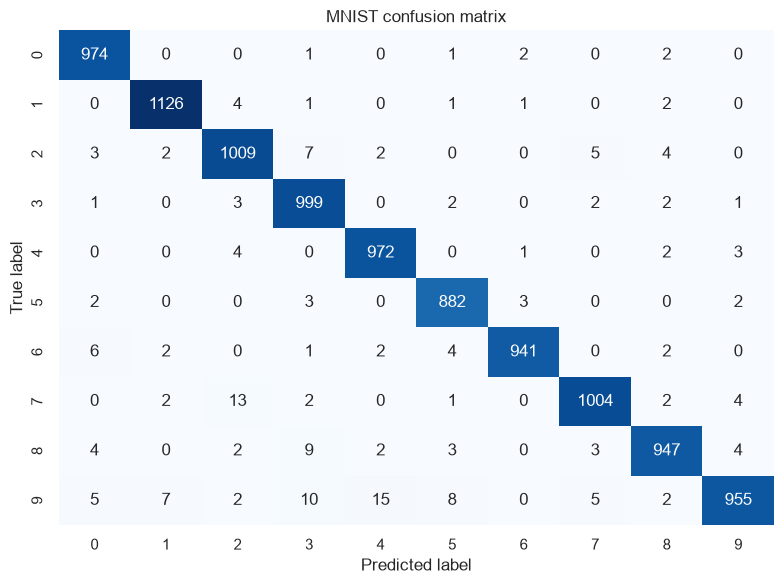

In [9]:
matrix = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("MNIST confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

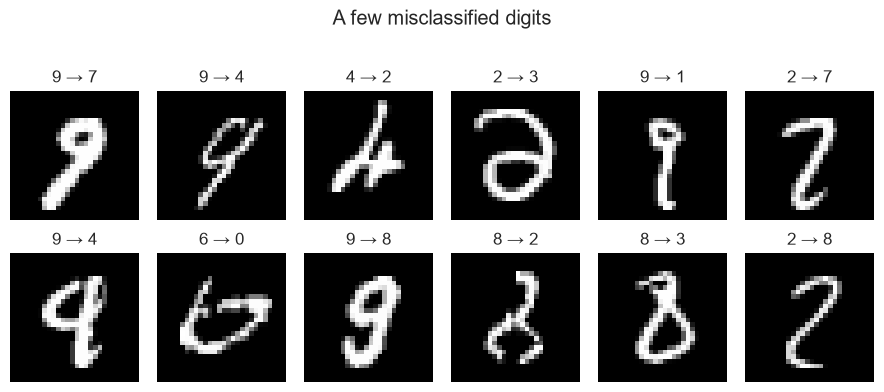

In [10]:
mistakes = np.flatnonzero(predictions != y_test)[:12]
fig, axes = plt.subplots(2, 6, figsize=(9, 4))
for index, ax in zip(mistakes, axes.flat):
    ax.imshow(x_test[index].squeeze(), cmap="gray")
    ax.set_title(f"{y_test[index]} → {predictions[index]}")
    ax.axis("off")
plt.suptitle("A few misclassified digits", y=1.02)
plt.tight_layout()

## Result

The CNN learns strong digit features from a limited training subset and generalizes well to the full MNIST test set. The confusion matrix and error examples reveal that the remaining mistakes mostly involve unusually written digits.

## Limits

- Training uses only part of the available training set to keep CPU runtime bounded.
- The architecture is intentionally small and is not tuned exhaustively.
- MNIST is clean and centered, so this result does not guarantee performance on handwriting captured in the wild.